# Modelling 2: SMOTE vs class weights, XGBoost, and an ensemble
Same problem as `MODEL.ipynb`. New here: (1) SMOTE applied **only to the training data**, (2) XGBoost, (3) an ensemble of all models, (4) a strict no-overlap train/test split.

## Plain-English glossary
| Term | Meaning |
|---|---|
| **Y / "at risk"** | The thing we predict: whether a respondent has **diabetes or prediabetes** (about 16% of people). |
| **Indicator / question** | One survey answer, e.g. high blood pressure, BMI, age. |
| **Rate (%)** | Out of 100 people in a group, how many have diabetes/prediabetes. |
| **Correlation** | A number from -1 to +1 showing how consistently two things move together. It shows association, **not** cause. |
| **Model** | A formula learned from past survey answers that gives each person a **risk score** between 0 and 1. |
| **Training / validation / test data** | Training = data the model learns from. Validation = used to tune settings. Test = data the model has never seen, used for the honest final grade. |
| **AUC (ROC-AUC)** | How well the model ranks risky people above safe ones. 0.5 = coin flip, 1.0 = perfect. ~0.82 here = decent, not perfect. |
| **PR-AUC** | Like AUC but stricter when the group we look for is rare. Random guessing scores about 0.16 (the share of at-risk people). |
| **Recall** | Of all people who really have diabetes, the share the model catches. |
| **Precision** | Of all people the model flags as high-risk, the share who really have diabetes. |
| **Threshold** | The cut-off score above which we call someone "high risk". Lower it: catch more diabetics but more false alarms. |
| **Imbalance** | Only ~16% of people are at risk, so a model saying "nobody has diabetes" is 84% accurate yet useless. We therefore don't judge on accuracy. |
| **Class weights / SMOTE** | Two ways to stop the model ignoring the rare group: weights make mistakes on at-risk people count more; SMOTE creates synthetic extra at-risk examples (training data only). |
| **Calibration** | Whether a predicted 20% risk really means about 20 in 100 people get diabetes. Needed before a score can set a price. |
| **Feature importance** | How much the model's accuracy drops if one question is scrambled. Big drop = the model relies on it. |


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import rankdata
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
sns.set_theme(style='whitegrid'); SEED=0

## 1. Strict train / validation / test split
The raw file has 23,899 exact duplicate rows, and 1,834 identical answer profiles carry conflicting labels. A random split would put identical respondents in both train and test and inflate the score. We split **by answer profile** (all rows with the same 21 answers go to the same split) and assert that no profile appears in more than one split. No rows are discarded.

In [2]:
raw = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
feats = [c for c in raw.columns if c != 'Diabetes_012']
print('rows:', len(raw), '| exact duplicate rows:', raw.duplicated().sum(), '| feature-profile duplicates:', raw.duplicated(feats).sum())
df = raw
y = (df.Diabetes_012 > 0).astype(int); X = df[feats]
grp = df.groupby(feats).ngroup()          # same answers -> same group
from sklearn.model_selection import StratifiedGroupKFold
def gsplit(idx, k):                        # hold out ~1/k of the groups, stratified on y
    tr, te = next(StratifiedGroupKFold(k, shuffle=True, random_state=SEED).split(idx, y[idx], grp[idx]))
    return idx[tr], idx[te]
tv, te = gsplit(np.arange(len(df)), 4)     # 75 / 25
tr, va = gsplit(tv, 5)                     # train 60 / val 15 of total
Xtr, ytr, Xva, yva, Xte, yte = X.iloc[tr], y.iloc[tr], X.iloc[va], y.iloc[va], X.iloc[te], y.iloc[te]
sets = {'train':set(grp.iloc[tr]), 'val':set(grp.iloc[va]), 'test':set(grp.iloc[te])}
assert not (sets['train']&sets['test']) and not (sets['val']&sets['test']) and not (sets['train']&sets['val'])
print('answer profiles shared between splits: 0 (asserted)')
print(pd.DataFrame({'rows':[len(Xtr),len(Xva),len(Xte)],'positive rate':[ytr.mean(),yva.mean(),yte.mean()]}, index=['train','val','test']).round(4))

rows: 253680 | exact duplicate rows: 23899 | feature-profile duplicates: 25772
answer profiles shared between splits: 0 (asserted)
         rows  positive rate
train  152497         0.1588
val     37980         0.1548
test    63203         0.1563


**Conclusion:** Splitting by answer profile guarantees no respondent profile is in two splits (asserted). All three splits keep a ~15.5-15.9% positive rate.

## 2. SMOTE on the training split only
Validation and test keep their real 16% positive rate.

> **How to read the chart below**
>
> Plain **SMOTE** creates fake extra 'diabetes' examples by blending real ones, so the model sees a balanced picture. It is applied to **training data only**.
> **Left:** the number of people in each class: training before SMOTE, training after SMOTE, and the test set. The test set is untouched, so the final grade is on real, unaltered data.
> **Right:** real answers to 'high blood pressure' are only 0 or 1 (blue). Synthetic rows (orange) include in-between values that no real person gave. This shows why SMOTE is an awkward fit for yes/no survey answers.

train before: 152497 pos rate 0.159 -> after SMOTE: 256556 pos rate 0.5
synthetic rows added: 104059
val/test untouched: 37980 63203 pos rate 0.155 0.156
fractional values in binary col HighBP (synthetic rows): 0.224


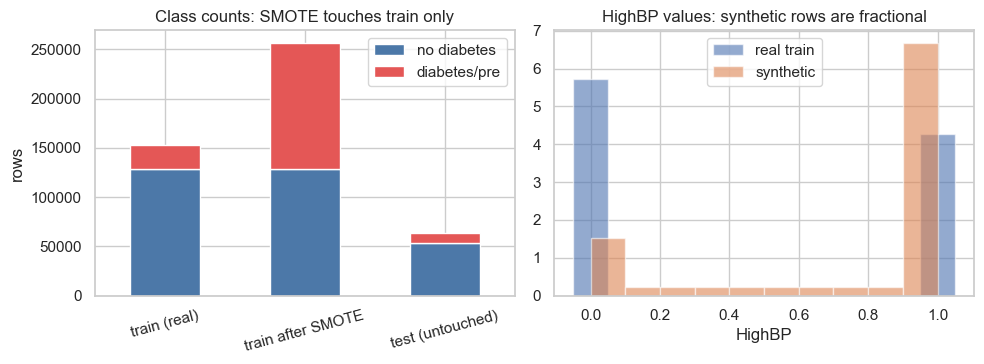

In [3]:
Xsm, ysm = SMOTE(random_state=SEED).fit_resample(Xtr, ytr)
print('train before:', len(Xtr), 'pos rate', ytr.mean().round(3), '-> after SMOTE:', len(Xsm), 'pos rate', ysm.mean().round(3))
print('synthetic rows added:', len(Xsm)-len(Xtr))
print('val/test untouched:', len(Xva), len(Xte), 'pos rate', yva.mean().round(3), yte.mean().round(3))
# synthetic rows interpolate between neighbours, so binary columns get fractional values
syn = Xsm.iloc[len(Xtr):]
print('fractional values in binary col HighBP (synthetic rows):', ((syn.HighBP%1)!=0).mean().round(3))
fig, ax = plt.subplots(1,2, figsize=(10,3.8))
pd.DataFrame({'train (real)':[(ytr==0).sum(),(ytr==1).sum()],'train after SMOTE':[(ysm==0).sum(),(ysm==1).sum()],'test (untouched)':[(yte==0).sum(),(yte==1).sum()]},
             index=['no diabetes','diabetes/pre']).T.plot.bar(stacked=True, ax=ax[0], rot=15, color=['#4c78a8','#e45756']); ax[0].set_title('Class counts: SMOTE touches train only'); ax[0].set_ylabel('rows')
ax[1].hist(Xtr.HighBP, bins=[-.05,.05,.95,1.05], alpha=.6, label='real train', density=True); ax[1].hist(syn.HighBP, bins=np.linspace(0,1,11), alpha=.6, label='synthetic', density=True)
ax[1].set_title('HighBP values: synthetic rows are fractional'); ax[1].set_xlabel('HighBP'); ax[1].legend(); plt.tight_layout(); plt.show()

**Note:** plain SMOTE interpolates, so binary survey answers (e.g. HighBP) become fractional in synthetic rows. This is a known weakness on survey/categorical data (`SMOTENC` is the categorical-aware version).

**Conclusion:** SMOTE adds 104k synthetic positives to train only (50/50). Val and test are untouched. About 22% of synthetic rows have a non-binary HighBP value, so SMOTE is a rough fit for survey answers.

## 3. Train every model two ways: class weights vs SMOTE
Plus XGBoost. Dummy is kept only as a reference and is excluded from the ensemble.

In [4]:
spw = (ytr==0).sum()/(ytr==1).sum()
def mk(name):
    return {
     'LogReg': lambda w: make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced' if w else None)),
     'RandomForest': lambda w: RandomForestClassifier(n_estimators=200, min_samples_leaf=50, class_weight='balanced_subsample' if w else None, n_jobs=-1, random_state=SEED),
     'HistGB': lambda w: HistGradientBoostingClassifier(class_weight='balanced' if w else None, random_state=SEED),
     'XGBoost': lambda w: XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                                        scale_pos_weight=spw if w else 1, eval_metric='logloss', n_jobs=-1, random_state=SEED),
    }[name]
names = ['LogReg','RandomForest','HistGB','XGBoost']
pva, pte = {}, {}
for n in names:
    for strat in ['weights','SMOTE']:
        m = mk(n)(strat=='weights')
        (m.fit(Xtr,ytr) if strat=='weights' else m.fit(Xsm,ysm))
        pva[f'{n} | {strat}'] = m.predict_proba(Xva)[:,1]; pte[f'{n} | {strat}'] = m.predict_proba(Xte)[:,1]
pte['Dummy'] = np.full(len(yte), ytr.mean())
print('done', len(pte)-1, 'models')

done 8 models


**Conclusion:** 8 models trained: 4 algorithms x 2 imbalance strategies.

## 4. Ensemble of all non-dummy models
Rank-average the probabilities (the weighted and SMOTE models are inflated on different scales, so ranks are safer than raw averaging). Three ensembles: weights-only, SMOTE-only, and all 8.

In [5]:
rk = lambda p: rankdata(p)/len(p)
def ens(P, keys): return np.mean([rk(P[k]) for k in keys], axis=0)
groups = {'Ensemble | weights (4)':[k for k in pva if k.endswith('weights')],
          'Ensemble | SMOTE (4)':[k for k in pva if k.endswith('SMOTE')],
          'Ensemble | all 8':list(pva)}
for g,keys in groups.items(): pva[g]=ens(pva,keys); pte[g]=ens(pte,keys)
res = pd.DataFrame({k:{'ROC-AUC':roc_auc_score(yte,v),'PR-AUC':average_precision_score(yte,v)} for k,v in pte.items()}).T.round(4).sort_values('PR-AUC',ascending=False)
res

,ROC-AUC,PR-AUC
XGBoost | weights,0.8238,0.4546
Ensemble | weights (4),0.8232,0.4516
HistGB | weights,0.8226,0.4510
Ensemble | all 8,0.8225,0.4498
RandomForest | weights,0.8203,0.4462
Ensemble | SMOTE (4),0.8203,0.4444
HistGB | SMOTE,0.8199,0.4436
XGBoost | SMOTE,0.8179,0.4409
RandomForest | SMOTE,0.8155,0.4325
LogReg | weights,0.8157,0.4219


> **How to read the chart below**
>
> **First chart, one bar per model, longer = better.** The measure is **PR-AUC** (see glossary; random guessing scores 0.156). Colours: **blue = class weights, red = SMOTE, green = ensemble of all 8 models**. The axis starts at 0.40 to make small gaps visible, so they look bigger than they are: the whole range is only about 0.03.
> **Second chart:** the same algorithms side by side, with class weights (blue) against SMOTE (red).
> **What to notice:** for every algorithm class weights tie or beat SMOTE, and the ensembles do not beat the best single model.

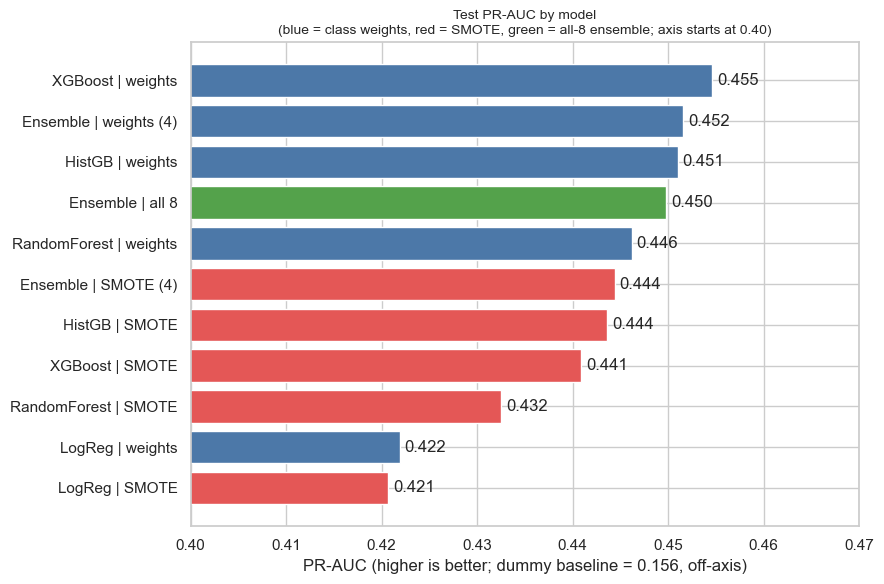

SMOTE vs weights, test PR-AUC:
              weights   SMOTE
LogReg         0.4219  0.4207
RandomForest   0.4462  0.4325
HistGB         0.4510  0.4436
XGBoost        0.4546  0.4409


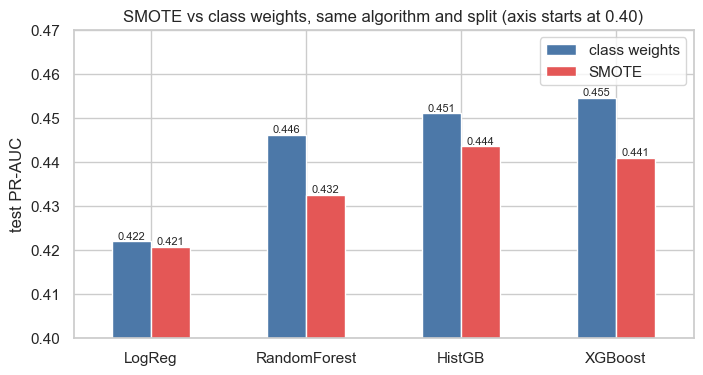

In [6]:
r = res.drop('Dummy').sort_values('PR-AUC')
col = ['#e45756' if 'SMOTE' in k else '#4c78a8' if 'weights' in k else '#54a24b' for k in r.index]
fig, ax = plt.subplots(figsize=(9,6))
ax.barh(r.index, r['PR-AUC'], color=col); ax.set_xlim(0.40, 0.47)
for i, v in enumerate(r['PR-AUC']): ax.text(v+0.0005, i, f'{v:.3f}', va='center')
ax.axvline(yte.mean(), c='k', ls='--'); 
ax.set_title('Test PR-AUC by model (blue = class weights, red = SMOTE, green = all-8 ensemble; axis starts at 0.40)'.replace(' (','\n(',1), fontsize=10)
ax.set_xlabel('PR-AUC (higher is better; dummy baseline = %.3f, off-axis)' % yte.mean()); plt.tight_layout(); plt.show()
print('SMOTE vs weights, test PR-AUC:')
print(pd.DataFrame({n:{'weights':res.loc[f'{n} | weights','PR-AUC'],'SMOTE':res.loc[f'{n} | SMOTE','PR-AUC']} for n in names}).T)
cmp = pd.DataFrame({n:{'class weights':res.loc[f'{n} | weights','PR-AUC'],'SMOTE':res.loc[f'{n} | SMOTE','PR-AUC']} for n in names}).T
ax = cmp.plot.bar(rot=0, figsize=(8,4), color=['#4c78a8','#e45756']); ax.set_ylim(0.40,0.47); ax.set_ylabel('test PR-AUC'); ax.set_title('SMOTE vs class weights, same algorithm and split (axis starts at 0.40)')
for p in ax.patches: ax.annotate(f'{p.get_height():.3f}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=8)
plt.show()

**Conclusion:** SMOTE did **not** help: for every algorithm, class weights score equal or better on PR-AUC (e.g. XGBoost 0.455 vs 0.441). XGBoost with weights is best, and the ensembles (0.444-0.452; the SMOTE-only one is lowest) don't beat it; the weights-based ones match the top single models. All models sit in a narrow band (ROC-AUC 0.814-0.824), so the data limits performance more than the algorithm.

## 5. Operating point: threshold chosen on validation, applied once to test
Cost assumption (change it): a missed diabetic costs 5x a false alarm.

> **How to read the chart below**
>
> One bar per model showing the **total assumed cost on the test data** (a missed diabetic costs 5, a false alarm 1), with each model's cut-off chosen beforehand on separate validation data. **Shorter = better.** The **dashed line** is the cost if we flagged nobody at all.
> **What to notice:** every model cuts cost to roughly half the dashed line, and the differences between models are small.

cost if everyone treated low-risk: 49390
                        precision  recall     F1  test cost
model                                                      
XGBoost | weights           0.342   0.767  0.473      26083
Ensemble | weights (4)      0.342   0.766  0.473      26132
HistGB | weights            0.341   0.767  0.472      26168
Ensemble | all 8            0.332   0.784  0.466      26245
RandomForest | weights      0.326   0.793  0.462      26412
Ensemble | SMOTE (4)        0.334   0.772  0.466      26484
HistGB | SMOTE              0.320   0.802  0.458      26587
XGBoost | SMOTE             0.328   0.780  0.462      26654
LogReg | weights            0.319   0.801  0.456      26700
LogReg | SMOTE              0.327   0.777  0.460      26812
RandomForest | SMOTE        0.318   0.799  0.455      26836


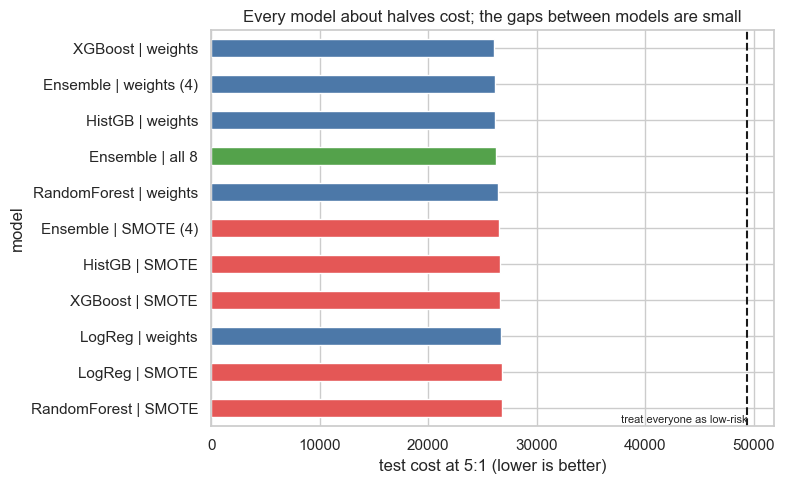

In [7]:
COST_FN, COST_FP = 5, 1
def pick(p, yy):
    ths = np.unique(np.quantile(p, np.linspace(0.02,0.98,97)))
    c = [COST_FN*((p<t)&(yy==1)).sum()+COST_FP*((p>=t)&(yy==0)).sum() for t in ths]; return ths[int(np.argmin(c))]
rows=[]
for k in pte:
    if k=='Dummy': continue
    t = pick(pva[k], yva); pr = pte[k]>=t
    cost = COST_FN*((~pr)&(yte==1)).sum()+COST_FP*(pr&(yte==0)).sum()
    rows.append((k, precision_score(yte,pr), recall_score(yte,pr), f1_score(yte,pr), cost))
op = pd.DataFrame(rows, columns=['model','precision','recall','F1','test cost']).set_index('model').round(3).sort_values('test cost')
print('cost if everyone treated low-risk:', COST_FN*yte.sum()); print(op.to_string())
o = op.sort_values('test cost', ascending=False)
ax = o['test cost'].plot.barh(figsize=(8,5), color=['#e45756' if 'SMOTE' in k else '#4c78a8' if 'weights' in k else '#54a24b' for k in o.index])
ax.axvline(COST_FN*yte.sum(), c='k', ls='--'); ax.text(COST_FN*yte.sum(), -0.4, ' treat everyone as low-risk', ha='right', fontsize=8)
ax.set_xlim(0, COST_FN*yte.sum()*1.05); ax.set_xlabel('test cost at 5:1 (lower is better)'); ax.set_title('Every model about halves cost; the gaps between models are small'); plt.tight_layout(); plt.show()

**Conclusion:** At a 5:1 cost ratio, every model cuts the assumed cost to about 26-27k from 49k (treating everyone as low-risk), catching 77-80% of diabetics at 32-34% precision. Differences between models are about 3%, which is small.

## 6. Calibration of the best model
Class-weighted scores are not true probabilities. Fit isotonic regression on the **validation** set to turn the score into a real risk, then check it on test.

> **How to read the chart below**
>
> Same calibration check as before: people sorted into 10 groups by predicted risk; **horizontal** = predicted risk, **vertical** = share who actually had diabetes; the **dashed diagonal** = perfectly honest probabilities.
> **What to notice:** the raw model (red) exaggerates risk; after recalibration (blue) it matches reality.

best: XGBoost | weights
mean predicted risk 0.155 | actual 0.156 | ROC-AUC 0.8234


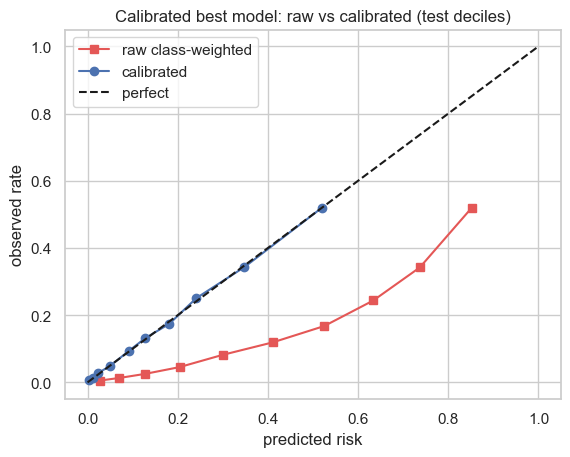

In [8]:
bestE = res.drop('Dummy').index[0]; print('best:', bestE)
iso = IsotonicRegression(out_of_bounds='clip').fit(pva[bestE], yva)
pc = iso.predict(pte[bestE]); praw = pte[bestE]  # raw class-weighted score
print('mean predicted risk %.3f | actual %.3f | ROC-AUC %.4f' % (pc.mean(), yte.mean(), roc_auc_score(yte,pc)))
q = pd.qcut(pc, 10, duplicates='drop'); d = pd.DataFrame({'pred':pc,'actual':yte.values}).groupby(q, observed=True).mean()
dr = pd.DataFrame({'pred':praw,'actual':yte.values}).groupby(pd.qcut(praw,10,duplicates='drop'), observed=True).mean(); plt.plot(dr.pred, dr.actual, marker='s', c='#e45756', label='raw class-weighted'); plt.plot(d.pred, d.actual, marker='o', label='calibrated'); plt.plot([0,1],[0,1],'k--',label='perfect'); plt.legend(); plt.xlabel('predicted risk'); plt.ylabel('observed rate'); plt.title('Calibrated best model: raw vs calibrated (test deciles)'); plt.show()

**Conclusion:** After isotonic calibration on validation, mean predicted risk matches the actual rate (0.155 vs 0.156) with AUC unchanged. Recommended model: XGBoost + class weights + calibration. It's simplest and top-ranked; the ensemble adds no accuracy.